## Data Loading & Initialization
This step initializes the analysis environment by importing core data manipulation and visualization libraries, then loading the engineered dataset.
* **Source File:** titanic_cleaned.csv
* **Storage Location:** Located within the local project structure under the ../data/processed/ directory, signifying that preliminary data cleaning and preprocessing stages are complete.
* **Data Pipeline:** Loading from the processed directory ensures that missing values (like missing age values) are already handled, and feature engineering steps are locked in before plotting begins.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv('../data/processed/titanic_cleaned.csv')

## `styling()` Helper Function

A reusable utility function designed to give Matplotlib axes a clean, modern, and publication-grade visual design.
### Key Enhancements
* **Clean Typography:** Uses soft off-black text (`#222222` / `#333333`) to prevent eye strain compared to harsh pure black.
* **Modern Title Alignment:** Left aligns the title (`loc='left'`) to follow natural eye movement from top left down the $y$-axis.
* **Decluttered Spines:** Removes unnecessary top and right borders while softening the remaining left and bottom axes (`#cccccc`).
* **Subtle Gridlines:** Applies light horizontal only dashed gridlines placed strictly *behind* data elements (`set_axisbelow(True)`).

In [2]:
def styling(ax, title="", xlabel="", ylabel=""):
    ax.set_title(title, fontsize=13, fontweight='bold', color='#222222', loc='left', pad=12)
    ax.set_xlabel(xlabel, fontsize=10, fontweight='medium', color='#333333', labelpad=8)
    ax.set_ylabel(ylabel, fontsize=10, fontweight='medium', color='#333333', labelpad=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.grid(True, axis='y', linestyle='--', alpha=0.5, color='#cccccc')
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', colors='#333333', labelsize=9)

## Bar Chart: Passenger Class vs. Survival Rate
This visualization analyzes how a passenger's socio economic status (Ticket Class) impacted their likelihood of survival.
* **X-Axis (Pclass):** The passenger class (1st, 2nd, or 3rd).
* **Y-Axis (Survival Rate):** The percentage of passengers within that specific class who survived.

Survival rate dropped sharply with passenger class, falling from **63.0% in 1st class** down to **47.3% in 2nd class**, and bottoming out at just **24.2% for passengers in 3rd class**.

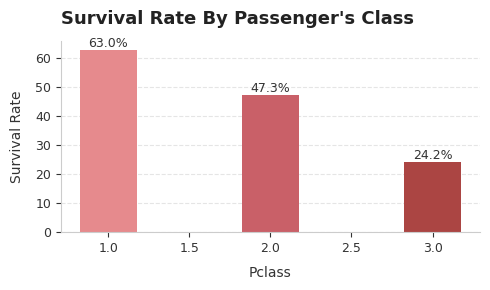

In [3]:
ab=df.groupby('Pclass')['Survived'].mean()*100
fig , ax =plt.subplots(figsize=(5,3))
bars=ax.bar(ab.index,ab.values,color=['#e68a8d','#c96068','#ab4543'], width=0.35)
styling(ax, title="Survival Rate By Passenger's Class", xlabel="Pclass", ylabel="Survival Rate")
for bar in bars:
    height=bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center',fontsize=9,fontweight='medium',color='#333333')
plt.tight_layout()
fig.savefig('../outputs/figures/survival_by_pclass.png', dpi=300, bbox_inches='tight')
plt.show()

## Bar Chart: Gender vs. Survival Rate
This visualization tracks the survival probability between male and female passengers, illustrating the impact of the historic "women and children first" evacuation protocol.
* **X-Axis (Sex):** Passenger gender (Female / Male).
* **Y-Axis (Survival Rate (%))**: The percentage of passengers within that gender group who survived.

There is a massive gender disparity in survival outcomes; **74% of female passengers** survived the disaster, compared to a meager **19% survival rate among male** passengers.

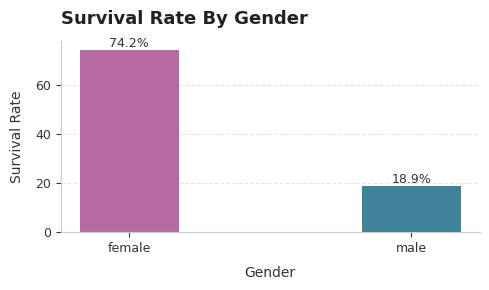

In [4]:
cd=df.groupby('Sex')['Survived'].mean()*100
fig , ax=plt.subplots(figsize=(5,3))
bars=ax.bar(cd.index, cd.values, color=["#b769a1", "#3F8299"],width=0.35)
styling(ax, title="Survival Rate By Gender", xlabel="Gender", ylabel="Survival Rate")
for bar in bars:
    height=bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center',fontsize=9,fontweight='medium',color='#333333')
plt.tight_layout()
fig.savefig('../outputs/figures/survival_by_gender.png', dpi=300, bbox_inches='tight')
plt.show()

## Bar Chart: Survival Rate by Class and Gender
This visualization uses a grouped bar chart to analyze the powerful intersection of socio economic status and gender, illustrating how these two factors combined to dictate survival priorities on the ship.
* **X-Axis (Pclass):** Passenger ticket class (1st, 2nd, and 3rd).
* **Y-Axis (Survival Rate (%)):** The percentage of passengers who survived within each specific class and gender group.

The data reveals a massive compounding effect between class and gender. 1st class women were almost universally saved with a 96.8% survival rate, dropping slightly to 92.1% in 2nd class, but plummeting to 50.0% for 3rd class women. For men, the situation was catastrophic across the board: even 1st class men only had a 36.9% survival rate, which shrank to an incredibly low 13.5% for 3rd class men.

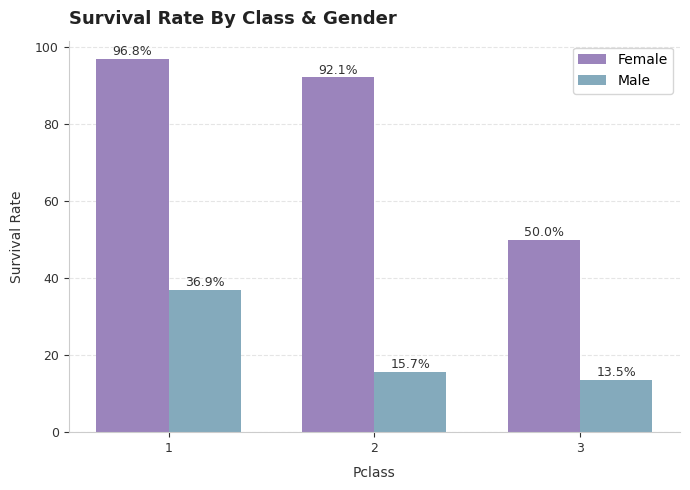

In [5]:
grouped = df.groupby(['Pclass','Sex'])['Survived'].mean().unstack() * 100
fig, ax = plt.subplots(figsize=(7,5))
x = np.arange(len(grouped.index))   
width = 0.35                         
bar1=ax.bar(x - width/2, grouped['female'], width, label='Female', color='#9b84bc')
bar2=ax.bar(x + width/2, grouped['male'], width, label='Male', color='#84aabc')
ax.set_xticks(x)
ax.set_xticklabels(grouped.index)
for group in [bar1, bar2]:
    for bar in group:
        height=bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2,height+1,f'{height:.1f}%',ha='center',fontsize=9,fontweight='medium',color='#333333')
styling(ax, title="Survival Rate By Class & Gender", xlabel="Pclass", ylabel="Survival Rate")
ax.legend()
plt.tight_layout()
fig.savefig('../outputs/figures/survival_by_class_and_gender.png', dpi=300, bbox_inches='tight')
plt.show()

## Histogram: Age Distribution: Survived vs. Deceased
This visualization uses overlapping histograms to compare the age distributions of passengers who survived against those who did not, helping to pinpoint which age groups were most vulnerable.
* **X-Axis (Age_Filled):** Passenger age, grouped into 10 consistent intervals (bins) spanning from infants to elderly travelers.
* **Y-Axis (Frequency/Count):** The raw number of passengers falling within each specific age bracket.

The distribution reveals a protective bias toward youth; children under the age of 5 (n=40) experienced a high survival rate of 67.5%, though this subgroup is small enough that the exact figure should be read with some caution. Conversely, the vast majority of casualties were heavily concentrated in the young adult demographic between 18 and 35 years old, where the number of deceased passengers sharply outpaced the survivors in every single bin.

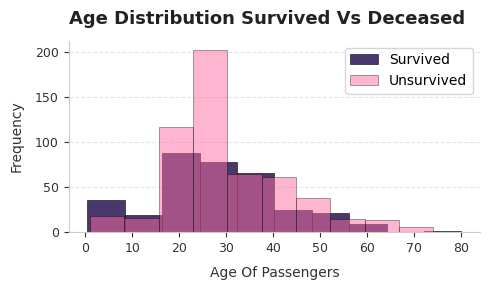

In [6]:
fig , ax= plt.subplots(figsize=(5,3))
ax.hist(df[df['Survived']==1]['Age_Filled'], bins=10, alpha=0.8, label='Survived', edgecolor='black', linewidth=0.5, color='#1c0646')
ax.hist(df[df['Survived']==0]['Age_Filled'], bins=10, alpha=0.5, label='Unsurvived',edgecolor='black', linewidth=0.5, color='#fd6ca3')
styling(ax, title="Age Distribution Survived Vs Deceased", xlabel="Age Of Passengers", ylabel="Frequency")
ax.legend()
plt.tight_layout()
fig.savefig('../outputs/figures/age_distribution_survived_vs_deceased.png', dpi=300, bbox_inches='tight')
plt.show()

## Bar Chart: Family Size Bracket vs. Survival Rate
This visualization tracks how traveling with family members affected a passenger's chances of survival, demonstrating that both isolation and excessively large group sizes lowered safety outcomes.
* **X-Axis (Family Band):** The categorized family size (typically segmented into groups like Alone, Small Family, and Large Family).
* **Y-Axis (Survival Rate):** The percentage of passengers within each bracket who survived.

Passengers traveling in Small Families (2–4 members) enjoyed the highest survival rate at roughly 57.9%, benefiting from mutual assistance without losing mobility. In contrast, those traveling Alone dropped to a 30.4% survival rate, while Large Families (5+ members) saw their survival chances crater to just 16.1%, reflecting the extreme difficulty of coordinating an escape together.

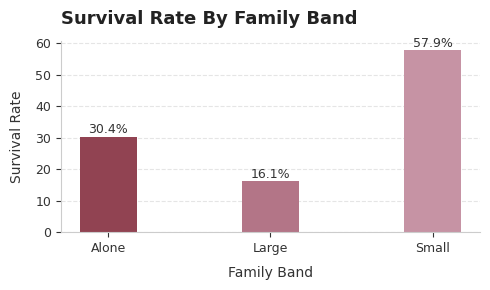

In [7]:
x=df.groupby('FamilyBand')['Survived'].mean()*100
fig , ax=plt.subplots(figsize=(5,3))
bars=ax.bar(x.index,x.values,color=['#914352','#b37587',"#c693a4"], width=0.35)
styling(ax, title="Survival Rate By Family Band", xlabel="Family Band", ylabel="Survival Rate")
for bar in bars:
    height=bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center',fontsize=9,fontweight='medium',color='#333333')
plt.tight_layout()
fig.savefig('../outputs/figures/survival_by_family_band.png', dpi=300, bbox_inches='tight')
plt.show()

### Histogram: Fare Per Person Distribution
This visualization examines the overall distribution of individual ticket costs, highlighting the heavy economic skew present among the passengers onboard.
* **X-Axis (Fare):** The ticket fare per person in British Pounds (£), grouped into 10 equal-width bins.
* **Y-Axis (Count):** The total number of passengers falling within each fare range.

The distribution is heavily rightskewed, showing that the vast majority of passengers were concentrated in the lowest price bracket (£0–£50). High fare passengers drop off sharply beyond £50, with only a small fraction of wealthy outliers paying luxury fares exceeding £100 to £200.

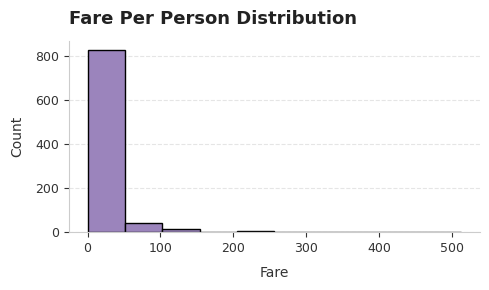

In [8]:
fig , ax =plt.subplots(figsize=(5,3))
ax.hist(df['Fare_Per_Person'], bins=10, edgecolor='black', color='#9b84bc')
styling(ax, title="Fare Per Person Distribution", xlabel="Fare", ylabel="Count")
plt.tight_layout()
fig.savefig('../outputs/figures/fare_per_person_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Scatter Plot: Age vs. Fare Per Person
This visualization explores the relationship between passenger age and individual ticket cost (`Fare_Per_Person`), revealing how purchasing power varied across age demographics and highlighting extreme outliers.
* **X-Axis (Age):** The passenger's age in years (imputed values included).
* **Y-Axis (Fare):** The individual fare paid per person in British Pounds (£).

While the majority of passengers across all age groups clustered in the lower fare tier (£0–£50), high-value fares (£100+) were overwhelmingly concentrated among middle-aged adults (roughly 30–50 years old). Very young passengers and elderly travelers rarely held top-tier tickets, though a few notable wealth outliers paid upwards of £200 to £500 regardless of age.

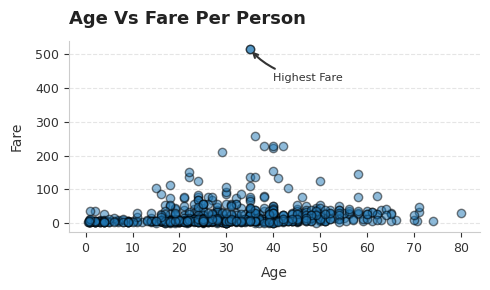

In [9]:
fig, ax=plt.subplots(figsize=(5,3))
ax.scatter(df['Age_Filled'],df['Fare_Per_Person'], alpha=0.5, edgecolor='black')
ax.annotate(
    "Highest Fare",
    xy=(35,512),
    xytext=(40,420),
    color='#333333',
    fontweight='medium',
    fontsize=8,
    arrowprops=dict(
        arrowstyle='->',
        color='#333333',
        lw=1.5,
        connectionstyle='arc3,rad=-0.2'
    )

)
styling(ax,title="Age Vs Fare Per Person", xlabel="Age", ylabel="Fare")
plt.tight_layout()
fig.savefig('../outputs/figures/age_vs_fare_per_person.png', dpi=300, bbox_inches='tight')
plt.show()